<a href="https://colab.research.google.com/github/marottiluc/Single_Lens_Fitting_LM/blob/main/roman_fspl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installations

In [1]:
# Run this cell if you are using Google Colab
!pip install pyLIMA

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 23.6 MB/s eta 0:00:0

In [2]:
from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model, FSPL_model
from pyLIMA.fits import LM_fit, DE_fit, MCMC_fit, TRF_fit
from pyLIMA.outputs import pyLIMA_plots
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    import google.colab
    %matplotlib inline
except ImportError:
    %matplotlib widget


In [3]:
# Download the data file from GitHub (run this cell if you are using Google Colab)
!wget -q https://raw.githubusercontent.com/ArjunMurlidhar/Single_Lens_Fitting/main/pylima_demo.txt

Reading Data File

In [4]:
#Read the data file
Roman_data = pd.read_table('pylima_demo.txt', sep='\s+', header=None)
Roman_data.columns = ['time', 'mag', 'err_mag']
Roman_data['time'] = Roman_data['time'].astype(float)
Roman_data['mag'] = Roman_data['mag'].astype(float)
Roman_data['err_mag'] = Roman_data['err_mag'].astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2774/502586899.py:2: SyntaxWarning: invalid escape sequence '\s'
  Roman_data = pd.read_table('pylima_demo.txt', sep='\s+', header=None)


In [5]:
#@title Basic pyLIMA Setup
# Create a new event
Roman_event = event.Event()
Roman_event.name = f'roman_fspl'

# Create synthetic data for demonstration
# In practice, you would load real data from files
np.random.seed(42)  # For reproducible results

# Create telescope object
lightcurve_data = np.column_stack(
    [
        Roman_data['time'],
        Roman_data['mag'],
        Roman_data['err_mag']
        ]
    )
Roman_W149 = telescopes.Telescope(
    name='Roman_W149',
    camera_filter='H',
    lightcurve=lightcurve_data.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['HJD', 'mag', 'mag']
)

# Add telescope to event
Roman_event.telescopes.append(Roman_W149)

# Set survey telescope (for alignment)
Roman_event.find_survey('Roman')

# Check event setup
Roman_event.check_event()

print(f"Event '{Roman_event.name}' created with {len(Roman_event.telescopes)} telescope(s)")
print(f"Data points: {len(Roman_W149.lightcurve)}")

check_event  : Everything looks fine...
Event 'roman_fspl' created with 1 telescope(s)
Data points: 38568


Fitting w/ Finite Source Point Lens Model

Selecting Roman_W149 to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2459657.748444, 0.6269400324057129, 5.076366999652237, 0.025, 691.3463548270483, 716.0997081422099]
fit  : Levenberg-Marquardt fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2459657.7827411117)),
             ('u0', np.float64(0.7970177907013488)),
             ('tE', np.float64(5.6612458634934555)),
             ('rho', np.float64(0.8267109864011976)),
             ('fsource_Roman_W149', np.float64(548.9677972919009)),
             ('ftotal_Roman_W149', np.float64(715.3305461223105)),
             ('chi2', np.float64(39992.30977701713))])

Fit Results:
[2.45965778e+06 7.97017791e-01 5.66124586e+00 8.26710986e-01
 5.48967797e+02 7.15330546e+02]


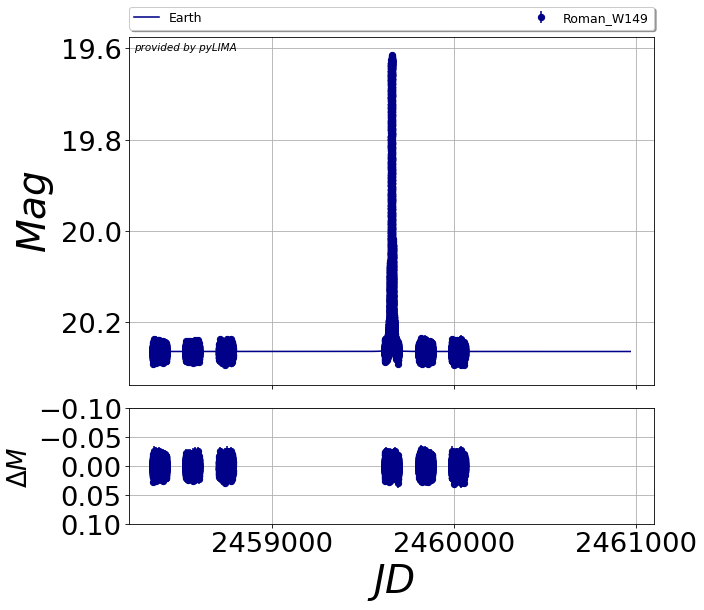

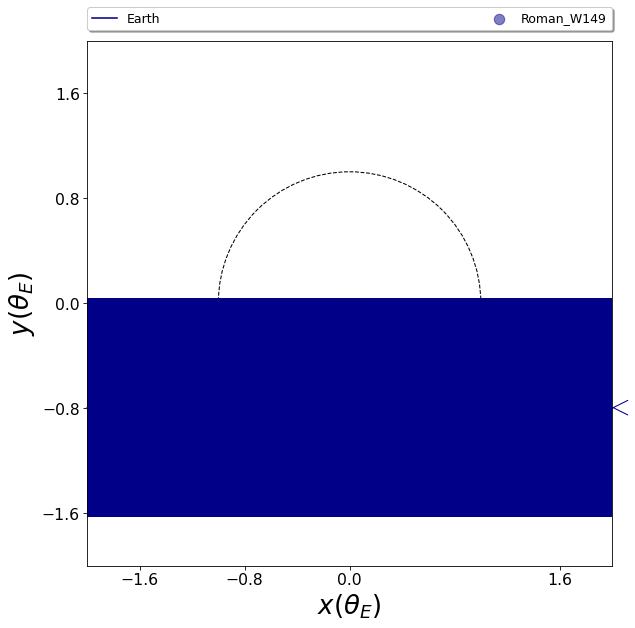

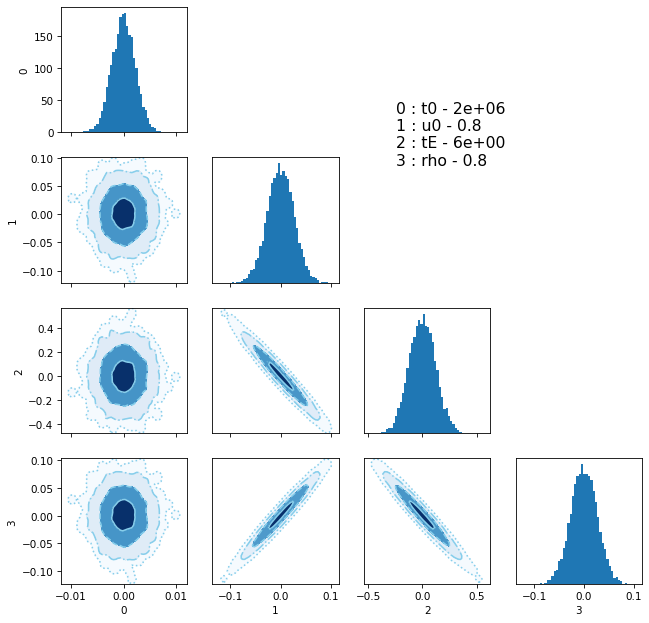

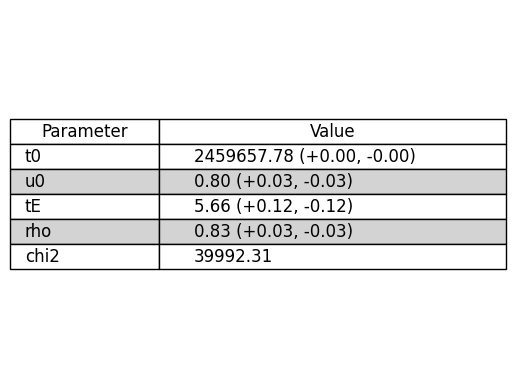

In [6]:
fspl = FSPL_model.FSPLmodel(Roman_event)

my_fit = LM_fit.LMfit(fspl)
my_fit.fit()
my_fit.fit_outputs()

# Display results
print("\nFit Results:")
print(my_fit.fit_results['best_model'])

In [7]:
delta_chi2 = my_fit.fit_results['chi2'] - (len(Roman_data['time']) - 5)
print(f"Delta Chi-squared: {delta_chi2:.2f}")
print("Reduced Chi-squared: ", my_fit.fit_results['chi2'] / (len(Roman_data['time']) - 5))

Delta Chi-squared: 1429.31
Reduced Chi-squared:  1.0370642786354052


Gathering t_E and t_0

In [8]:
t_0 = my_fit.fit_results['best_model'][0]
t_E = my_fit.fit_results['best_model'][2]
print("t0 = ",t_0)
print("tE = ",t_E)

t0 =  2459657.7827411117
tE =  5.6612458634934555


Using t_E and t_0 to crop data and plot

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2774/3815453049.py:5: SyntaxWarning: invalid escape sequence '\s'
  Roman_data = pd.read_table('pylima_demo.txt', sep='\s+', header=None)


Original data points: 38568
Cropping time range: [2459629.48, 2459686.09]
Cropped data points: 5054


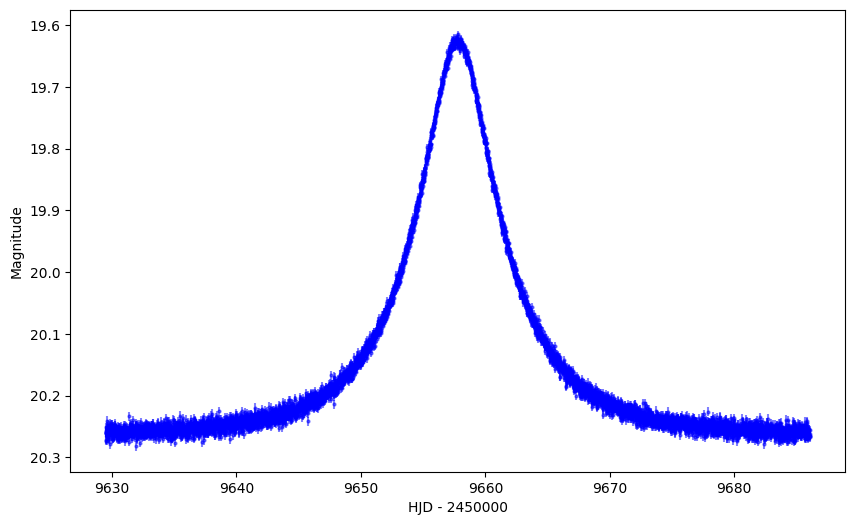

In [9]:
t_0 = my_fit.fit_results['best_model'][0]
t_E = my_fit.fit_results['best_model'][2]

# Read the data file and assign column names immediately
Roman_data = pd.read_table('pylima_demo.txt', sep='\s+', header=None)
Roman_data.columns = ['time', 'mag', 'err_mag']

# Convert relevant columns to float
Roman_data['time'] = Roman_data['time'].astype(float)
Roman_data['mag'] = Roman_data['mag'].astype(float)
Roman_data['err_mag'] = Roman_data['err_mag'].astype(float)

#Print data point values
print(f"Original data points: {len(Roman_data)}")
print(f"Cropping time range: [{(t_0 - 5 * t_E):.2f}, {(t_0 + 5 * t_E):.2f}]")

# Crop data to t_0 - 5*t_E to t_0 + 5*t_E
data_cropped = Roman_data[(Roman_data['time'] >= (t_0 - 5 * t_E)) & (Roman_data['time'] <= (t_0 + 5 * t_E))]

print(f"Cropped data points: {len(data_cropped)}")

# Plot the light curve with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(data_cropped['time'] - 2450000, data_cropped['mag'], yerr=data_cropped['err_mag'], fmt='o', c='blue', alpha=0.5, markersize=2.0)
plt.xlabel('HJD - 2450000')
plt.ylabel('Magnitude')
#plt.xlim((9620, 9700))
#invert the y-axis
plt.gca().invert_yaxis()
plt.show()

In [10]:
#@title Basic pyLIMA Setup
# Create a new event
Roman_event_cropped = event.Event()
Roman_event_cropped.name = f'roman_fspl_cropped'

# Create synthetic data for demonstration
# In practice, you would load real data from files
np.random.seed(42)  # For reproducible results

# Create telescope object
lightcurve_data = np.column_stack(
    [
        data_cropped['time'],
        data_cropped['mag'],
        data_cropped['err_mag']
        ]
    )
Roman_W149 = telescopes.Telescope(
    name='Roman_W149',
    camera_filter='H',
    lightcurve=lightcurve_data.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['HJD', 'mag', 'mag']
)

# Add telescope to event
Roman_event_cropped.telescopes.append(Roman_W149)

# Set survey telescope (for alignment)
Roman_event_cropped.find_survey('Roman')

# Check event setup
Roman_event_cropped.check_event()

print(f"Event '{Roman_event_cropped.name}' created with {len(Roman_event_cropped.telescopes)} telescope(s)")
print(f"Data points: {len(Roman_W149.lightcurve)}")

check_event  : Everything looks fine...
Event 'roman_fspl_cropped' created with 1 telescope(s)
Data points: 5054



Running LM fit...
Selecting Roman_W149 to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2459657.743181, 0.635931829120665, 4.792631666641682, 0.025, 705.9903338666959, 725.0843865548237]
fit  : Levenberg-Marquardt fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2459657.7823557514)),
             ('u0', np.float64(0.34117975604005635)),
             ('tE', np.float64(8.210261813761244)),
             ('rho', np.float64(0.24052350665597858)),
             ('fsource_Roman_W149', np.float64(248.8743390301043)),
             ('ftotal_Roman_W149', np.float64(715.4006322152405)),
             ('chi2', np.float64(5166.626328616499))])

Fit Results:
[2.45965778e+06 3.41179756e-01 8.21026181e+00 2.40523507e-01
 2.48874339e+02 7.15400632e+02]

Chi-squared: 5166.63


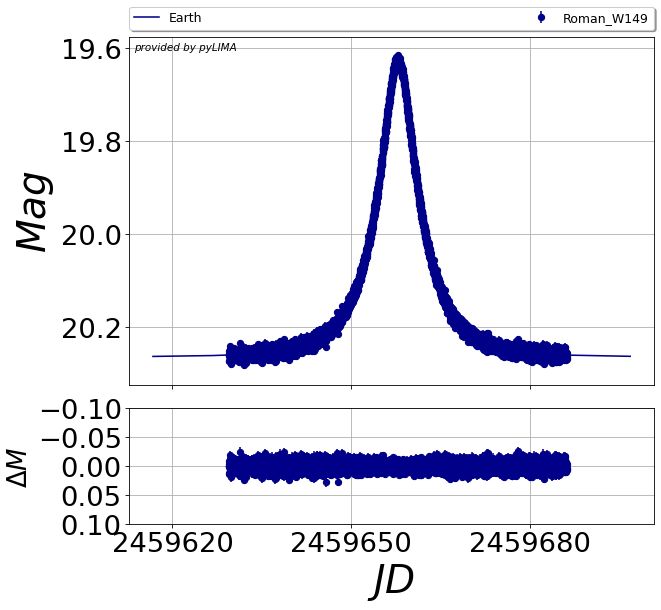

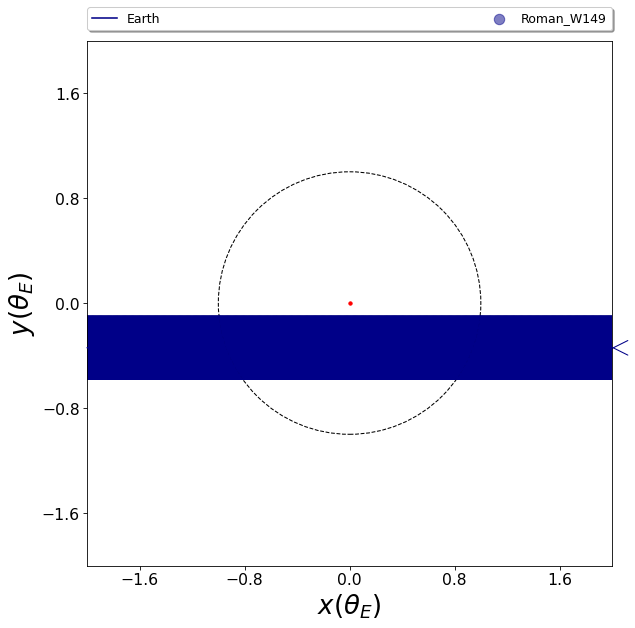

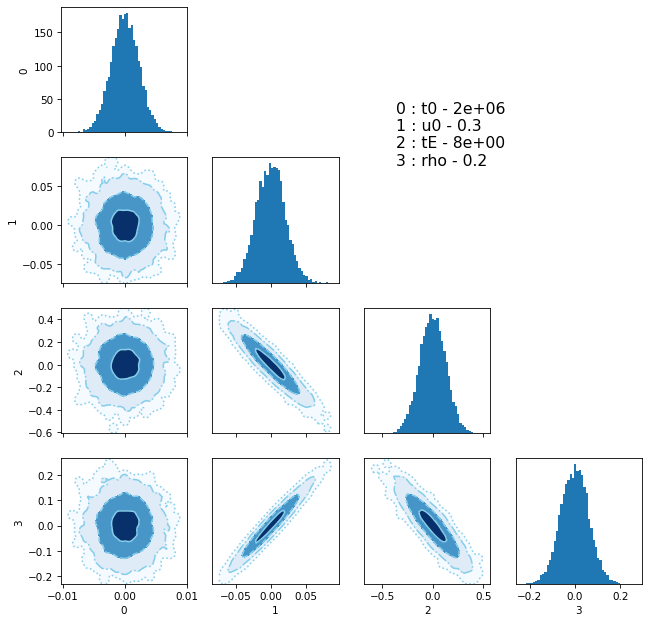

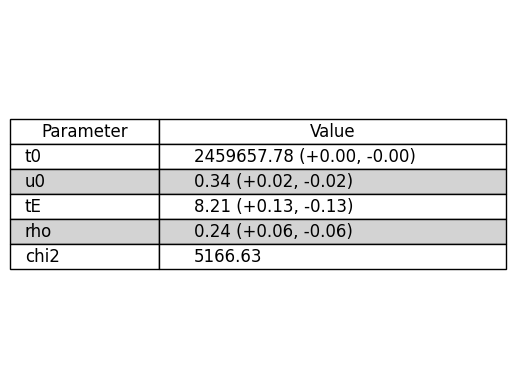

In [11]:
#@title FSPL Model Setup and Fitting
# Create FSPL model
fspl = FSPL_model.FSPLmodel(Roman_event_cropped)

# Initialize fit with Levenberg-Marquardt algorithm
my_fit_cropped = LM_fit.LMfit(fspl)

# Run the fit
print("\nRunning LM fit...")
my_fit_cropped.fit()
my_fit_cropped.fit_outputs()

# Display results
print("\nFit Results:")
print(my_fit_cropped.fit_results['best_model'])
print(f"\nChi-squared: {my_fit_cropped.fit_results['chi2']:.2f}")

In [12]:
delta_chi2 = my_fit_cropped.fit_results['chi2'] - (len(data_cropped['time']) - 5)
print(f"Delta Chi-squared: {delta_chi2:.2f}")
print("Reduced Chi-squared: ", my_fit_cropped.fit_results['chi2'] / (len(data_cropped['time']) - 5))

Delta Chi-squared: 117.63
Reduced Chi-squared:  1.0232969555588234


In [17]:
with open("fspl_file_test.txt", "w") as f:
    f.write("Created using write mode.\n")
    f.write("Second line.\n")
    f.write("\nChi-Squared\n")
    f.write(str(my_fit_cropped.fit_results['chi2']))
    f.write("\n\nBest Model\n")
    f.write(str(my_fit_cropped.fit_results['best_model']))
    f.write("\n\nt_E\n")
    f.write((str(my_fit_cropped.fit_results['best_model'][2])))

with open("fspl_file_test.txt", "r") as f:
    print(f.read())

Created using write mode.
Second line.

Chi-Squared
5166.626328616499

Best Model
[2.45965778e+06 3.41179756e-01 8.21026181e+00 2.40523507e-01
 2.48874339e+02 7.15400632e+02]

t_E
8.210261813761244
